In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [6]:
df = pd.read_csv("ecommerce_bigdata.csv")

df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [7]:
print(df.shape)

df.info()

df.describe(include='all')

(200, 7)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    200 non-null    str    
 1   Date             200 non-null    str    
 2   Region           200 non-null    str    
 3   ProductCategory  200 non-null    str    
 4   CustomerType     200 non-null    str    
 5   Sales            200 non-null    int64  
 6   Profit           200 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 11.1 KB


,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
count,200,200,200,200,200,200.000000,200.000000
unique,200,120,4,5,3,NaN,NaN
top,TX0001,2026-05-28,Eastern,Beverages,Wholesale,NaN,NaN
freq,1,6,60,52,82,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2567.190000,456.367350
std,NaN,NaN,NaN,NaN,NaN,1528.736925,346.853151
min,NaN,NaN,NaN,NaN,NaN,56.000000,5.130000
25%,NaN,NaN,NaN,NaN,NaN,1200.500000,173.967500
50%,NaN,NaN,NaN,NaN,NaN,2428.000000,379.330000
75%,NaN,NaN,NaN,NaN,NaN,4052.000000,675.000000


In [8]:
print(df.isnull().sum())

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64


In [9]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\user\AppData\Local\Temp\ipykernel_22212\2877434760.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [10]:
df = df.drop_duplicates()

In [11]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])
    

C:\Users\user\AppData\Local\Temp\ipykernel_22212\3420757603.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


In [12]:
X = df.drop("CustomerType", axis=1)

y = df["CustomerType"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# logistic regression model

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.25
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.19      0.30      0.23        10
           2       0.39      0.35      0.37        20

    accuracy                           0.25        40
   macro avg       0.19      0.22      0.20        40
weighted avg       0.24      0.25      0.24        40



c:\Users\user\Desktop\RECESS ASSIGNMENTS\MAGURU_ANTHONY\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


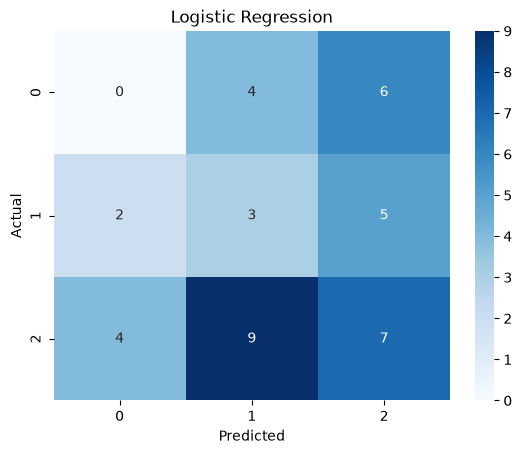

In [ ]:
# confusion matrix for logistic regression
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [16]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy: 0.2
              precision    recall  f1-score   support

           0       0.08      0.10      0.09        10
           1       0.06      0.10      0.08        10
           2       0.55      0.30      0.39        20

    accuracy                           0.20        40
   macro avg       0.23      0.17      0.18        40
weighted avg       0.31      0.20      0.23        40



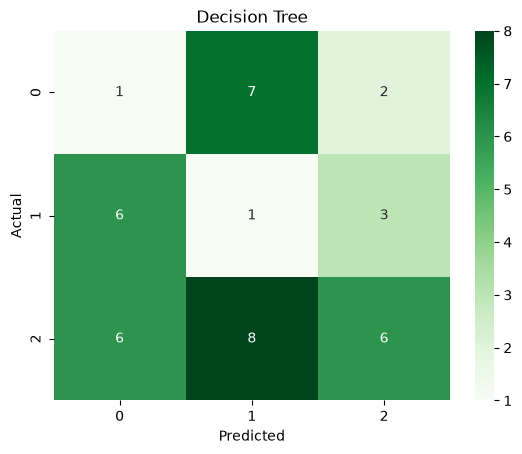

In [ ]:
# confusion matrix for decision tree
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.275
              precision    recall  f1-score   support

           0       0.08      0.10      0.09        10
           1       0.17      0.20      0.18        10
           2       0.50      0.40      0.44        20

    accuracy                           0.28        40
   macro avg       0.25      0.23      0.24        40
weighted avg       0.31      0.28      0.29        40



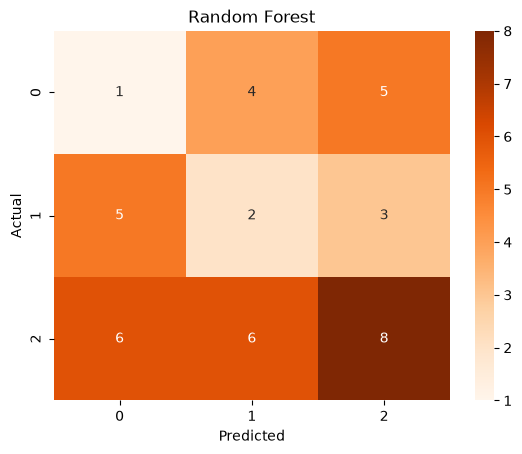

In [19]:
# confusion matris for random forest
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# Comparison of model performance
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

results.sort_values(by="Accuracy", ascending=False)

                 Model  Accuracy
0  Logistic Regression     0.250
1        Decision Tree     0.200
2        Random Forest     0.275


,Model,Accuracy
2,Random Forest,0.275
0,Logistic Regression,0.250
1,Decision Tree,0.200


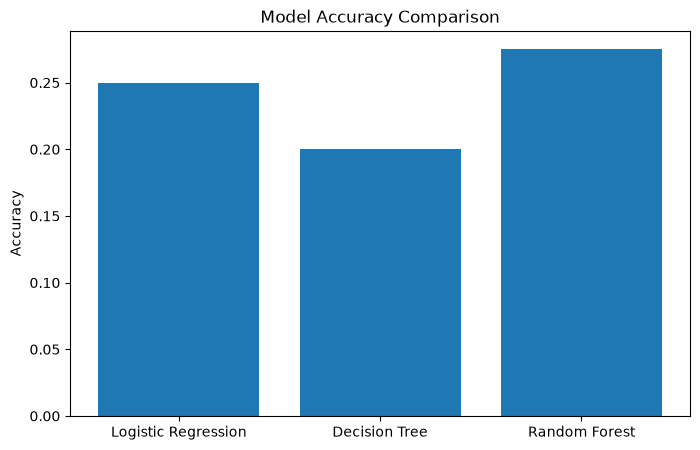

In [21]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()